# ============================================================
# Data Mining – All Assignments Combined
# Mir Anas Ali Khan
# CPSC 6790 – Governors State University, Spring 2026
# Dataset: MAIN FILE_MAN_UNITED.csv
# =======================================================

ASSIGNMENT 2 – Impurity Measures
Shots_cat: Gini=0.497, Entropy=1.203, Error=0.38
xG_cat: Gini=0.41, Entropy=1.059, Error=0.26
Poss_cat: Gini=0.539, Entropy=1.324, Error=0.38
Fouls_cat: Gini=0.539, Entropy=1.325, Error=0.38

ASSIGNMENT 3 – Decision Tree Classification
Underfitting Model
Train Accuracy: 0.674
Test Accuracy: 0.632
Tree Depth: 1
Leaves: 2

Overfitting Model
Train Accuracy: 1.0
Test Accuracy: 0.579
Tree Depth: 7
Leaves: 10

Missing values before handling:
Result                           0
Shots                            0
Shots on Target                  0
Expected Goals                  12
Possession (%)                   1
Passes Completion Percentage    12
Interception                     0
Yellow Card                      0
Goals Against                    1
dtype: int64

Missing values after handling:
Result                          0
Shots                           0
Shots on Target                 0
Expected Goals                  0
Possession (%)                 

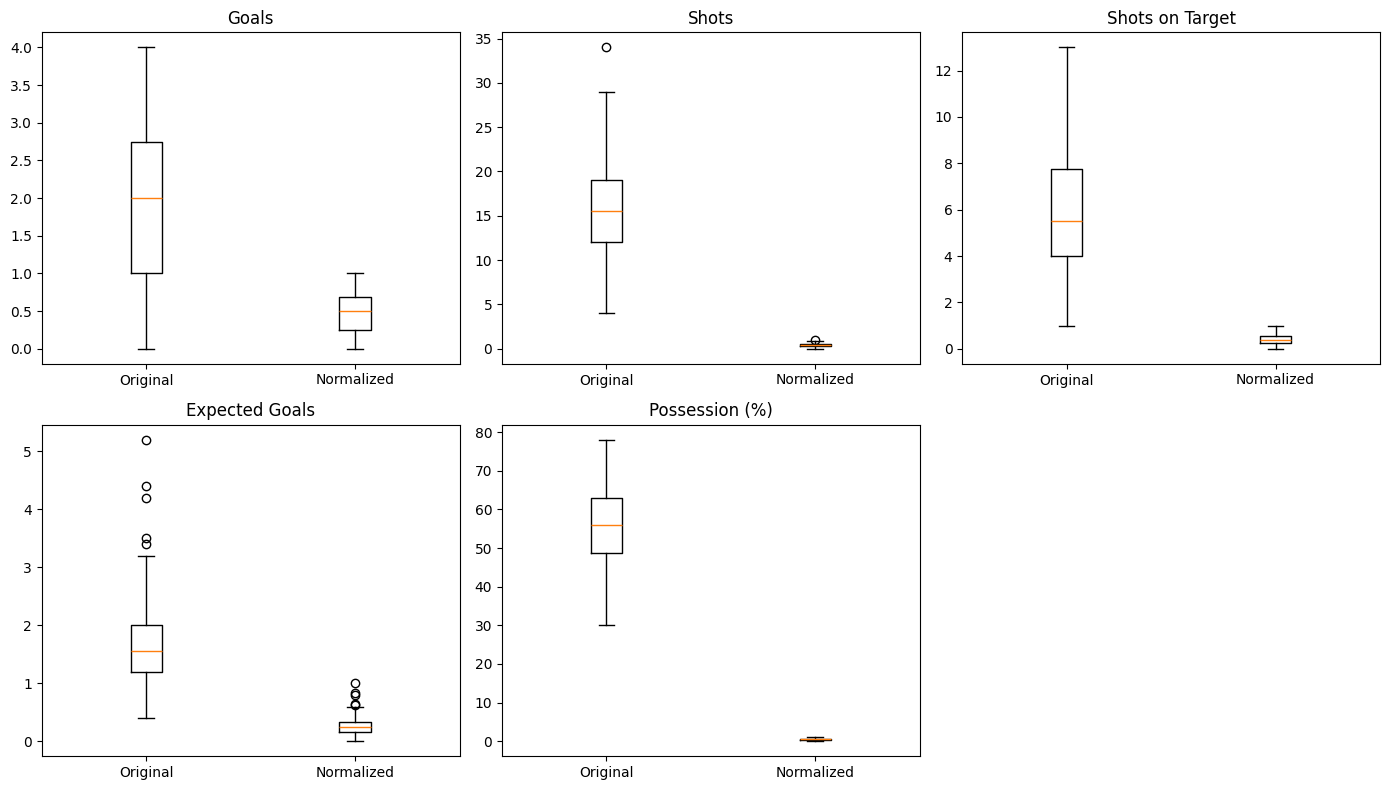

                 Sample  Matches  Avg Goals  Avg Shots  Avg xG  Win Rate
0          Full Dataset       62      1.774     16.161   1.774     0.661
1     Random 50% Sample       31      1.871     17.452   1.823     0.677
2     Random 70% Sample       43      1.860     15.651   1.710     0.674
3  Bootstrap 50% Sample       31      1.742     16.452   1.753     0.742


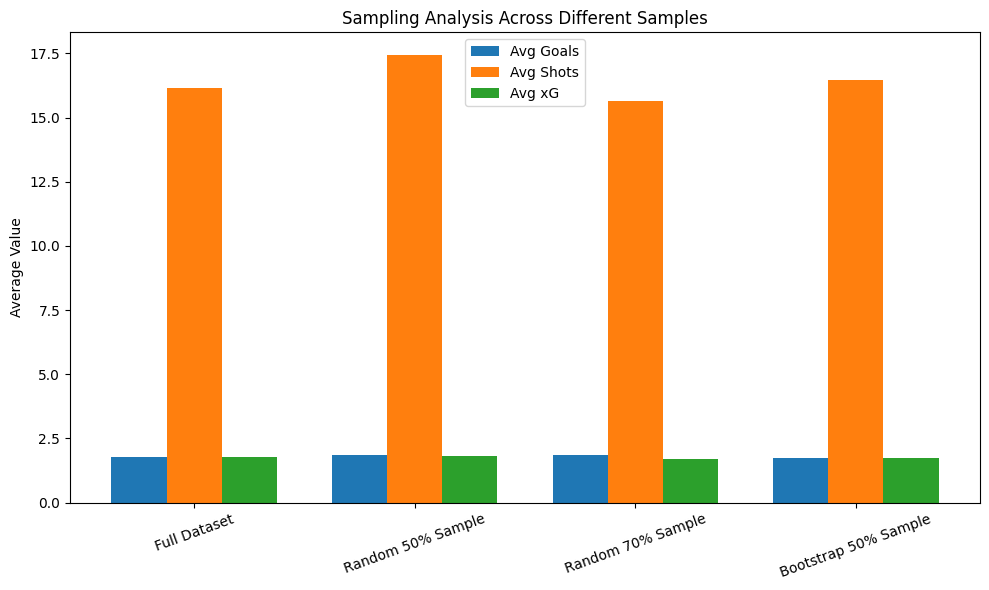

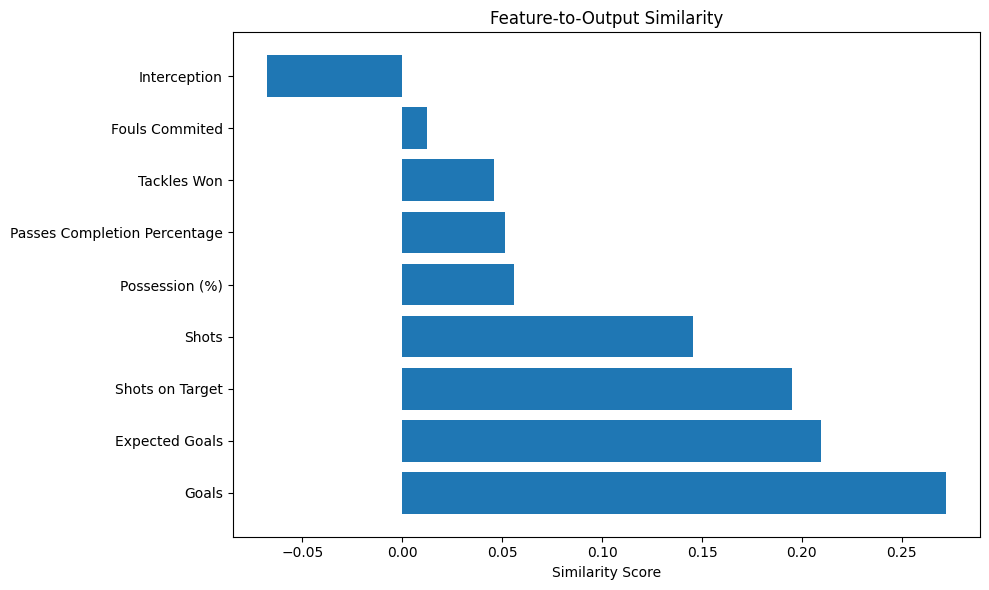

            Feature       Chi2   p_value  dof
0             Venue  12.911630  0.011716    4
1        Shot_Level   6.163501  0.187266    4
3  Discipline_Level   4.980309  0.289324    4
2  Possession_Level   1.311544  0.859414    4


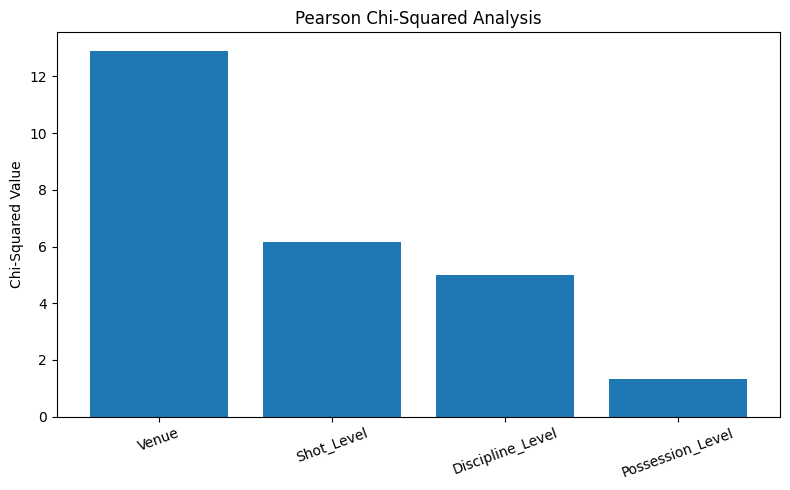

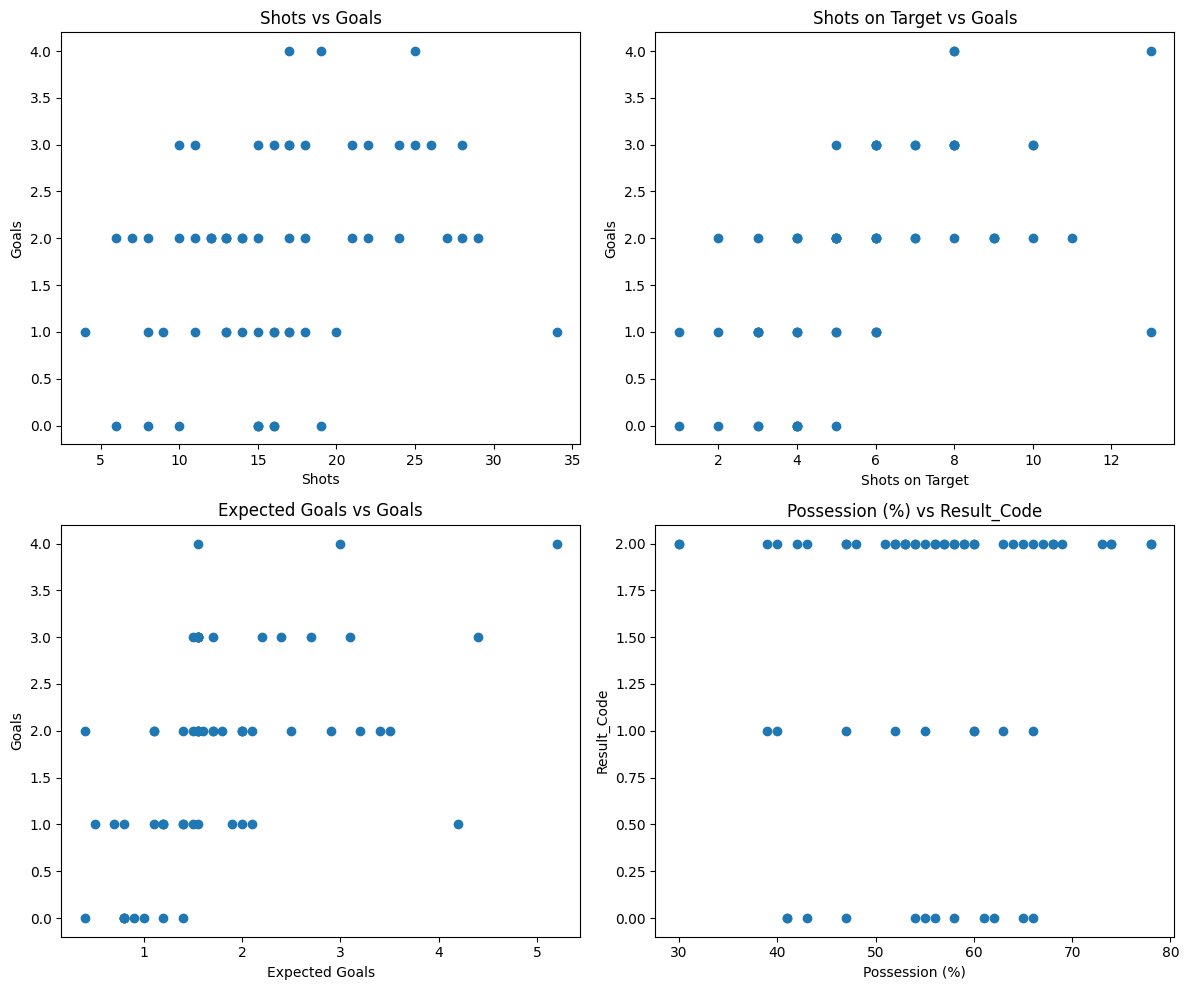

                        Feature    Mean  Median   Mode  Variance
0                         Goals   1.774    2.00   2.00     1.194
1                         Shots  16.161   15.50  15.00    39.744
2               Shots on Target   5.774    5.50   6.00     7.161
3                Expected Goals   1.774    1.55   1.55     0.916
4  Passes Completion Percentage  80.498   80.90  80.90    19.729
5                Possession (%)  55.823   56.00  47.00   117.886
6                   Tackles Won  10.548   10.00  10.00    13.071
7                  Interception   8.855    8.00   8.00    14.716
8                Fouls Commited  11.032   11.00  12.00     6.097


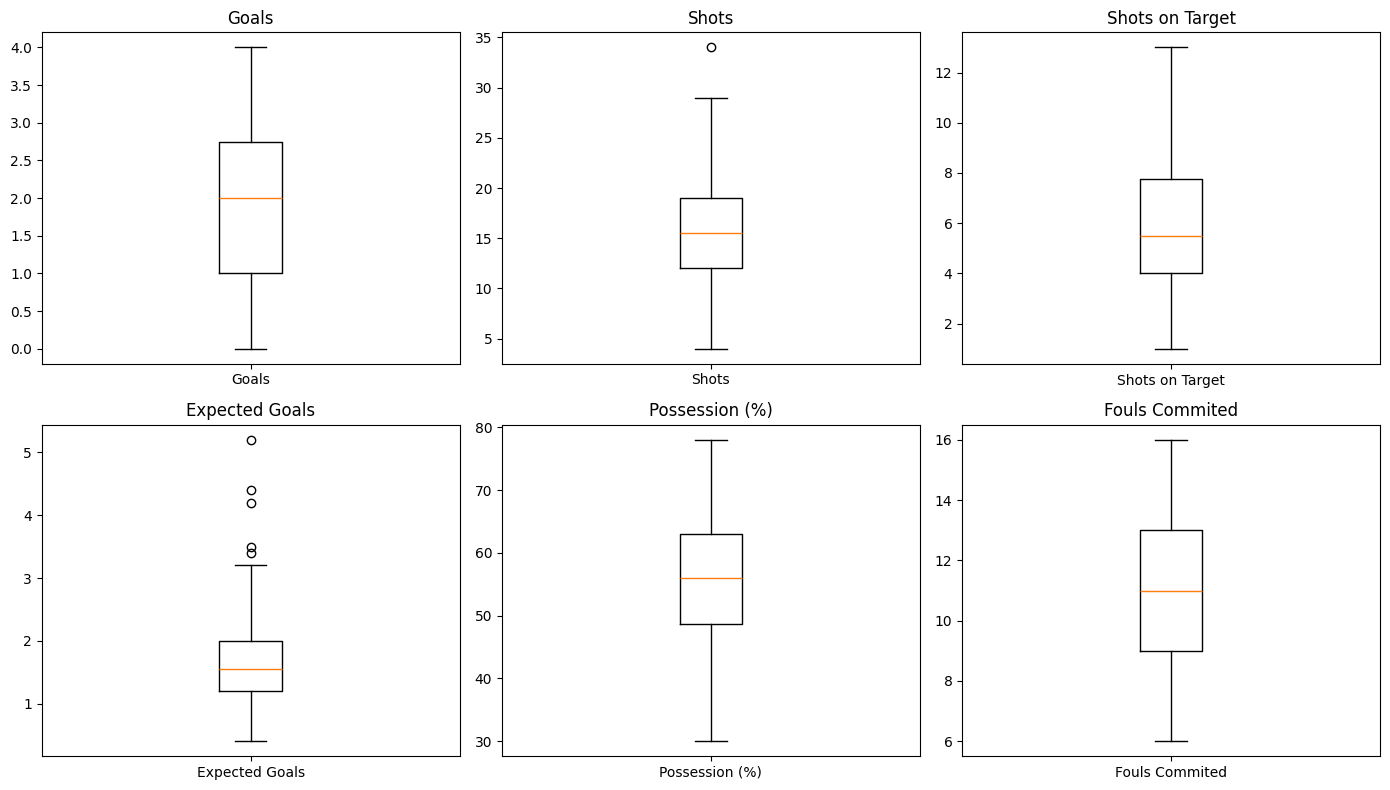

          Feature       Date         Opponent Result  Value
0           Shots        NaT        AC Omonia      W   34.0
1  Expected Goals        NaT        AC Omonia      W    4.2
2  Expected Goals        NaT   Leicester City      W    4.4
3  Expected Goals 2023-08-04          Everton      W    3.4
4  Expected Goals        NaT  Nott'ham Forest      W    3.5


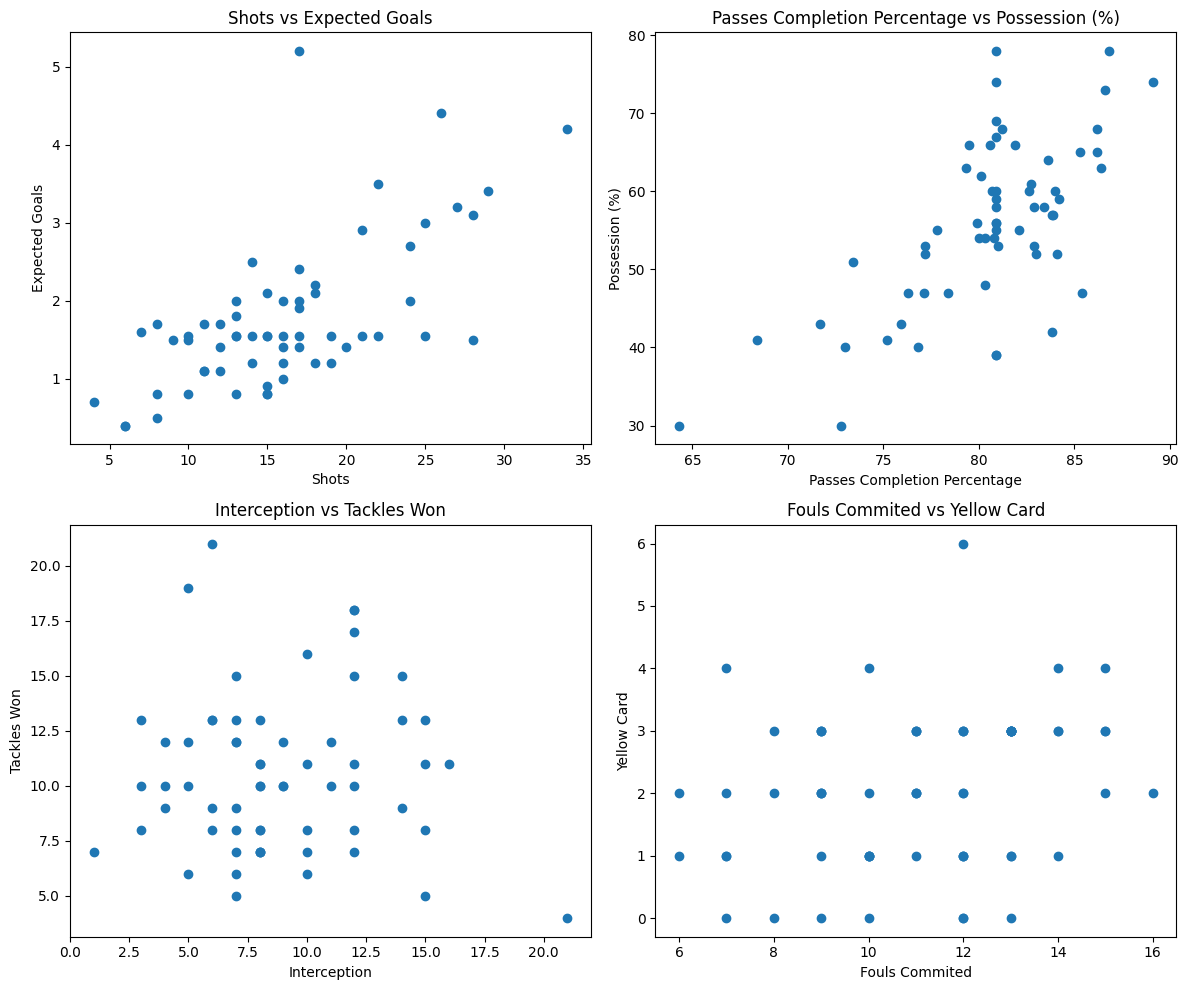

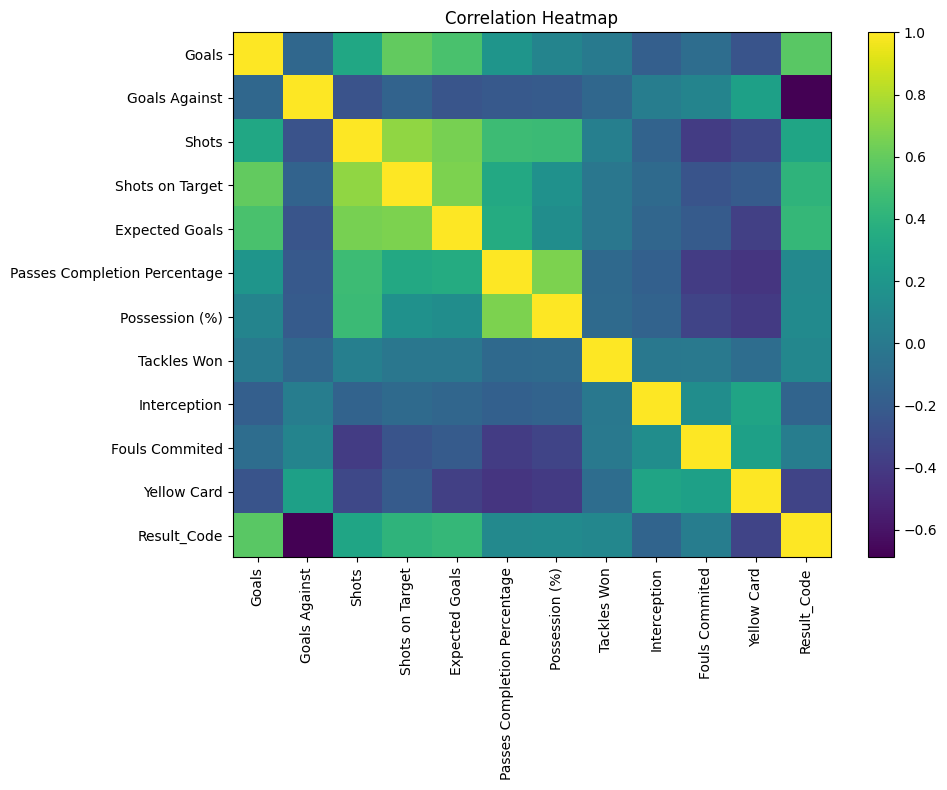

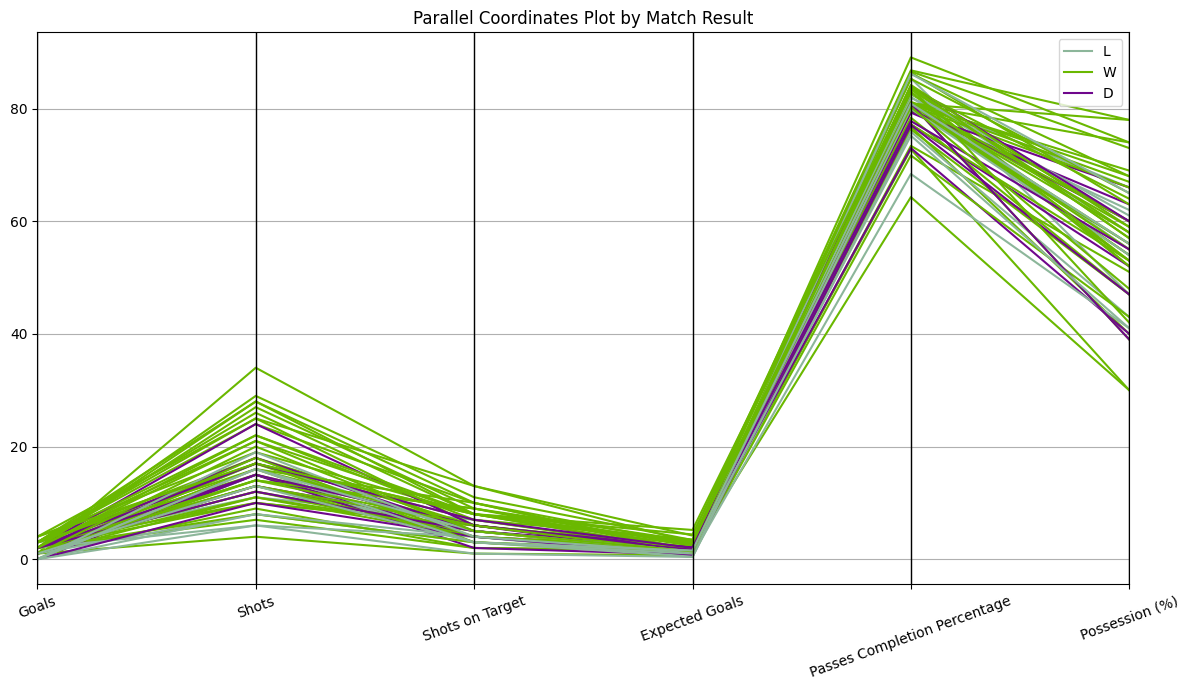


ASSIGNMENT 5 – Model Evaluation
Training/Test split
Training size: (49, 8)
Test size: (13, 8)
Model Accuracy: 0.8461538461538461
Result (Win, Draw, Lost)
1    41
0    21
Name: count, dtype: int64
Train class counts:
Result (Win, Draw, Lost)
1    32
0    17
Name: count, dtype: int64
Test class counts:
Result (Win, Draw, Lost)
1    9
0    4
Name: count, dtype: int64

Confusion Matrix:
[[4 0]
 [0 9]]
TN: 4
FP: 0
FN: 0
TP: 9

Normal Accuracy: 1.0
Normal Accuracy %: 100.0
Total Cost: -9

Random Subsampling Scores: [0.6923076923076923, 0.8461538461538461, 0.6923076923076923, 0.7692307692307693, 0.8461538461538461, 0.8461538461538461, 0.6923076923076923, 0.7692307692307693, 0.7692307692307693, 0.7692307692307693]
Average Random Subsampling Accuracy: 0.7692307692307693

Cross-Validation Scores: [0.69230769 0.76923077 0.91666667 0.91666667 0.83333333]
Average CV Accuracy: 0.8256410256410256

Bootstrap Scores: [0.9230769230769231, 1.0, 0.8461538461538461, 1.0, 0.8461538461538461, 0.923076923076

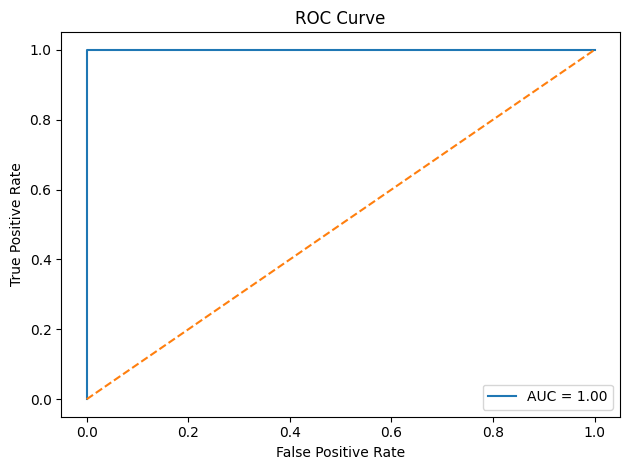

AUC Score: 1.0

Mean Accuracy: 0.8256410256410256
90% Confidence Interval: (np.float64(0.7332181512895243), np.float64(0.9180638999925268))
95% Confidence Interval: (np.float64(0.7052726020059987), np.float64(0.9460094492760525))

All assignments complete.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from pandas.plotting import parallel_coordinates
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.utils import resample
from scipy import stats


# ============================================================
# ASSIGNMENT 2 – Impurity Measures
# (Gini Index, Entropy, Misclassification Error)
# ============================================================

print("=" * 60)
print("ASSIGNMENT 2 – Impurity Measures")
print("=" * 60)

df2 = pd.read_csv("MAIN FILE_MAN_UNITED.csv")

df2 = df2[["Result", "Shots", "Expected Goals", "Possession (%)", "Fouls Commited"]]
df2 = df2.dropna()
df2 = df2[df2["Result"].isin(["W", "D", "L"])]

df2["Shots_cat"]  = pd.cut(df2["Shots"],             bins=[-1, 10, 20, 100], labels=["Low", "Medium", "High"])
df2["xG_cat"]     = pd.cut(df2["Expected Goals"],     bins=[-1, 1, 100],     labels=["Low", "High"])
df2["Poss_cat"]   = pd.cut(df2["Possession (%)"],     bins=[-1, 50, 100],    labels=["Low", "High"])
df2["Fouls_cat"]  = pd.cut(df2["Fouls Commited"],     bins=[-1, 10, 100],    labels=["Low", "High"])


def impurity(df, feature, target="Result"):
    values = df[feature].unique()
    gini_total = entropy_total = error_total = 0

    for v in values:
        subset = df[df[feature] == v]
        p = subset[target].value_counts(normalize=True)

        gini    = 1 - sum(p ** 2)
        entropy = -sum(p * np.log2(p + 1e-9))
        error   = 1 - max(p)
        weight  = len(subset) / len(df)

        gini_total    += weight * gini
        entropy_total += weight * entropy
        error_total   += weight * error

    return gini_total, entropy_total, error_total


features_a2 = ["Shots_cat", "xG_cat", "Poss_cat", "Fouls_cat"]

for f in features_a2:
    g, e, m = impurity(df2, f)
    print(f"{f}: Gini={round(g, 3)}, Entropy={round(e, 3)}, Error={round(m, 3)}")


# ============================================================
# ASSIGNMENT 3 – Decision Tree: Overfitting vs Underfitting
# (Missing Value Handling + Generalization Error Estimation)
# ============================================================

print()
print("=" * 60)
print("ASSIGNMENT 3 – Decision Tree Classification")
print("=" * 60)

df3 = pd.read_csv("MAIN FILE_MAN_UNITED.csv")

features_underfit = ["Fouls Commited"]
features_overfit  = [
    "Shots", "Shots on Target", "Expected Goals",
    "Possession (%)", "Passes Completion Percentage",
    "Interception", "Yellow Card", "Goals Against"
]
target = "Result"

all_features = list(set(features_underfit + features_overfit))
data3 = df3[[target] + all_features].copy()

for col in all_features:
    data3[col] = pd.to_numeric(data3[col], errors="coerce")

data3 = data3[data3["Result"].isin(["W", "D", "L"])].copy()

X3 = data3[all_features]
y3 = data3[target]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.30, random_state=42, stratify=y3
)

# ── Underfitting model ────────────────────────────────────────
underfit_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(max_depth=1, min_samples_leaf=5, random_state=42))
])
underfit_model.fit(X3_train[features_underfit], y3_train)

uf_train_pred = underfit_model.predict(X3_train[features_underfit])
uf_test_pred  = underfit_model.predict(X3_test[features_underfit])

print("Underfitting Model")
print("Train Accuracy:", round(accuracy_score(y3_train, uf_train_pred), 3))
print("Test Accuracy:",  round(accuracy_score(y3_test,  uf_test_pred),  3))
print("Tree Depth:",     underfit_model.named_steps["tree"].get_depth())
print("Leaves:",         underfit_model.named_steps["tree"].get_n_leaves())
print()

# ── Overfitting model ─────────────────────────────────────────
overfit_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42))
])
overfit_model.fit(X3_train[features_overfit], y3_train)

of_train_pred = overfit_model.predict(X3_train[features_overfit])
of_test_pred  = overfit_model.predict(X3_test[features_overfit])

print("Overfitting Model")
print("Train Accuracy:", round(accuracy_score(y3_train, of_train_pred), 3))
print("Test Accuracy:",  round(accuracy_score(y3_test,  of_test_pred),  3))
print("Tree Depth:",     overfit_model.named_steps["tree"].get_depth())
print("Leaves:",         overfit_model.named_steps["tree"].get_n_leaves())
print()

# ── Missing value handling ────────────────────────────────────
selected_cols = [
    "Result", "Shots", "Shots on Target", "Expected Goals",
    "Possession (%)", "Passes Completion Percentage",
    "Interception", "Yellow Card", "Goals Against"
]
data_mv = df3[selected_cols].copy()
numeric_cols = [c for c in selected_cols if c != "Result"]

for col in numeric_cols:
    data_mv[col] = pd.to_numeric(data_mv[col], errors="coerce")

print("Missing values before handling:")
print(data_mv.isna().sum())
print()

imputer_mv = SimpleImputer(strategy="median")
data_mv[numeric_cols] = imputer_mv.fit_transform(data_mv[numeric_cols])

print("Missing values after handling:")
print(data_mv.isna().sum())
print()

# ── Generalization error estimation ───────────────────────────
data_ge = df3[["Result"] + features_overfit].copy()
for col in features_overfit:
    data_ge[col] = pd.to_numeric(data_ge[col], errors="coerce")
data_ge = data_ge[data_ge["Result"].isin(["W", "D", "L"])].copy()

X_ge = data_ge[features_overfit]
y_ge = data_ge["Result"]

X_ge_train, X_ge_test, y_ge_train, y_ge_test = train_test_split(
    X_ge, y_ge, test_size=0.30, random_state=42, stratify=y_ge
)

ge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42))
])
ge_model.fit(X_ge_train, y_ge_train)

train_pred_ge = ge_model.predict(X_ge_train)
test_pred_ge  = ge_model.predict(X_ge_test)

train_errors = (train_pred_ge != y_ge_train).sum()
test_errors  = (test_pred_ge  != y_ge_test).sum()
n_train      = len(y_ge_train)
leaves_ge    = ge_model.named_steps["tree"].get_n_leaves()

optimistic_error  = train_errors / n_train
pessimistic_error = (train_errors + 0.5 * leaves_ge) / n_train

print("Training samples:",               n_train)
print("Training errors:",                train_errors)
print("Test errors:",                    test_errors)
print("Leaves:",                         leaves_ge)
print("Optimistic resubstitution error:", round(optimistic_error, 3))
print("Pessimistic error estimate:",     round(pessimistic_error, 3))


# ============================================================
# MAIN DATA MINING ASSIGNMENT – Full Exploration Pipeline
# (Cleaning, Normalization, Sampling, Similarity, Chi-Square,
#  Correlation, Statistics, Outliers, 10 Visualizations)
# ============================================================

print()
print("=" * 60)
print("MAIN DATA MINING ASSIGNMENT – Full Exploration")
print("=" * 60)

OUTPUT_DIR = "soccer_assignment_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_main = pd.read_csv("MAIN FILE_MAN_UNITED.csv")
print("Original shape:", df_main.shape)

# ── Select columns ────────────────────────────────────────────
selected_columns = [
    "Date", "Opponent", "Venue", "Result",
    "Goals", "Goals Against", "Shots", "Shots on Target",
    "Expected Goals", "Passes Completion Percentage",
    "Possession (%)", "Tackles Won", "Interception",
    "Fouls Commited", "Yellow Card"
]
soccer = df_main[selected_columns].copy()

# ── Basic cleaning ────────────────────────────────────────────
soccer["Date"] = pd.to_datetime(soccer["Date"], errors="coerce")

numeric_columns = [
    "Goals", "Goals Against", "Shots", "Shots on Target",
    "Expected Goals", "Passes Completion Percentage",
    "Possession (%)", "Tackles Won", "Interception",
    "Fouls Commited", "Yellow Card"
]

for col in numeric_columns:
    soccer[col] = pd.to_numeric(soccer[col], errors="coerce")

soccer = soccer.drop_duplicates()

for col in numeric_columns:
    soccer[col] = soccer[col].fillna(soccer[col].median())

for col in ["Opponent", "Venue", "Result"]:
    soccer[col] = soccer[col].fillna(soccer[col].mode()[0])

soccer = soccer[soccer["Result"].isin(["W", "D", "L"])].copy()

result_map = {"L": 0, "D": 1, "W": 2}
soccer["Result_Code"] = soccer["Result"].map(result_map)

# ── Feature engineering (bins) ────────────────────────────────
soccer["Shot_Level"] = pd.cut(
    soccer["Shots"],
    bins=[-np.inf, 12, 18, np.inf],
    labels=["Low Shots", "Medium Shots", "High Shots"]
)
soccer["Possession_Level"] = pd.cut(
    soccer["Possession (%)"],
    bins=[-np.inf, 50, 60, np.inf],
    labels=["Low Possession", "Medium Possession", "High Possession"]
)
soccer["Discipline_Level"] = pd.cut(
    soccer["Fouls Commited"],
    bins=[-np.inf, 9, 13, np.inf],
    labels=["Better Discipline", "Average Discipline", "Poorer Discipline"]
)

soccer.to_csv(os.path.join(OUTPUT_DIR, "cleaned_soccer_dataset.csv"), index=False)
print("Cleaned shape:", soccer.shape)

# ── 4. Normalization ──────────────────────────────────────────
norm_features = ["Goals", "Shots", "Shots on Target", "Expected Goals", "Possession (%)"]

scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(soccer[norm_features])
normalized_df = pd.DataFrame(normalized_values, columns=norm_features)

plt.figure(figsize=(14, 8))
for i, col in enumerate(norm_features, 1):
    plt.subplot(2, 3, i)
    plt.boxplot([soccer[col], normalized_df[col]], labels=["Original", "Normalized"])
    plt.title(col)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_normalization_boxplots.png"), dpi=300)
plt.show()

# ── 5. Sampling analysis ──────────────────────────────────────
def sample_summary(data, label):
    return {
        "Sample":    label,
        "Matches":   len(data),
        "Avg Goals": round(data["Goals"].mean(), 3),
        "Avg Shots": round(data["Shots"].mean(), 3),
        "Avg xG":    round(data["Expected Goals"].mean(), 3),
        "Win Rate":  round((data["Result"] == "W").mean(), 3)
    }

sample_50    = soccer.sample(frac=0.50, random_state=42)
sample_70    = soccer.sample(frac=0.70, random_state=24)
bootstrap_50 = soccer.sample(frac=0.50, replace=True, random_state=7)

sample_df = pd.DataFrame([
    sample_summary(soccer,       "Full Dataset"),
    sample_summary(sample_50,    "Random 50% Sample"),
    sample_summary(sample_70,    "Random 70% Sample"),
    sample_summary(bootstrap_50, "Bootstrap 50% Sample"),
])

sample_df.to_csv(os.path.join(OUTPUT_DIR, "sample_summary.csv"), index=False)
print(sample_df)

plt.figure(figsize=(10, 6))
x = np.arange(len(sample_df))
bar_width = 0.25
plt.bar(x - bar_width, sample_df["Avg Goals"], width=bar_width, label="Avg Goals")
plt.bar(x,             sample_df["Avg Shots"], width=bar_width, label="Avg Shots")
plt.bar(x + bar_width, sample_df["Avg xG"],   width=bar_width, label="Avg xG")
plt.xticks(x, sample_df["Sample"], rotation=20)
plt.ylabel("Average Value")
plt.title("Sampling Analysis Across Different Samples")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_sampling_analysis.png"), dpi=300)
plt.show()

# ── 6. Similarity analysis ────────────────────────────────────
similarity_features = [
    "Goals", "Shots", "Shots on Target", "Expected Goals",
    "Passes Completion Percentage", "Possession (%)",
    "Tackles Won", "Interception", "Fouls Commited"
]

similarity_matrix = soccer[similarity_features].corr()
similarity_matrix.to_csv(os.path.join(OUTPUT_DIR, "similarity_matrix.csv"))

std_scaler    = StandardScaler()
scaled_f      = std_scaler.fit_transform(soccer[similarity_features])
output_values = soccer["Result_Code"].values.reshape(-1, 1)

feature_output_similarity = []
for i, feature in enumerate(similarity_features):
    score = cosine_similarity(
        scaled_f[:, i].reshape(1, -1),
        output_values.reshape(1, -1)
    )[0][0]
    feature_output_similarity.append([feature, score])

sim_df = pd.DataFrame(
    feature_output_similarity, columns=["Feature", "Cosine Similarity"]
).sort_values(by="Cosine Similarity", ascending=False)

sim_df.to_csv(os.path.join(OUTPUT_DIR, "feature_output_similarity.csv"), index=False)

plt.figure(figsize=(10, 6))
plt.barh(sim_df["Feature"], sim_df["Cosine Similarity"])
plt.xlabel("Similarity Score")
plt.title("Feature-to-Output Similarity")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_similarity_analysis.png"), dpi=300)
plt.show()

# ── 7. Chi-Square analysis ────────────────────────────────────
categorical_features = ["Venue", "Shot_Level", "Possession_Level", "Discipline_Level"]

chi_results = []
for col in categorical_features:
    table = pd.crosstab(soccer[col], soccer["Result"])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append([col, chi2, p, dof])

chi_df = pd.DataFrame(chi_results, columns=["Feature", "Chi2", "p_value", "dof"])
chi_df = chi_df.sort_values(by="Chi2", ascending=False)
chi_df.to_csv(os.path.join(OUTPUT_DIR, "chi_square_results.csv"), index=False)
print(chi_df)

plt.figure(figsize=(8, 5))
plt.bar(chi_df["Feature"], chi_df["Chi2"])
plt.title("Pearson Chi-Squared Analysis")
plt.ylabel("Chi-Squared Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_chi_square.png"), dpi=300)
plt.show()

# ── 8. Pearson correlation analysis ──────────────────────────
corr_features = [
    "Goals", "Goals Against", "Shots", "Shots on Target",
    "Expected Goals", "Passes Completion Percentage",
    "Possession (%)", "Tackles Won", "Interception",
    "Fouls Commited", "Yellow Card", "Result_Code"
]

correlation_matrix = soccer[corr_features].corr(method="pearson")
correlation_matrix.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix.csv"))

scatter_pairs = [
    ("Shots",           "Goals"),
    ("Shots on Target", "Goals"),
    ("Expected Goals",  "Goals"),
    ("Possession (%)",  "Result_Code"),
]

plt.figure(figsize=(12, 10))
for i, (x_col, y_col) in enumerate(scatter_pairs, 1):
    plt.subplot(2, 2, i)
    plt.scatter(soccer[x_col], soccer[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_correlation_scatterplots.png"), dpi=300)
plt.show()

# ── 9. Statistical measures ───────────────────────────────────
stats_df = pd.DataFrame({
    "Feature":  similarity_features,
    "Mean":     [soccer[c].mean()      for c in similarity_features],
    "Median":   [soccer[c].median()    for c in similarity_features],
    "Mode":     [soccer[c].mode()[0]   for c in similarity_features],
    "Variance": [soccer[c].var()       for c in similarity_features],
}).round(3)

stats_df.to_csv(os.path.join(OUTPUT_DIR, "06_statistical_measures.csv"), index=False)
print(stats_df)

# ── 10. Box plots and outlier analysis ────────────────────────
box_features = [
    "Goals", "Shots", "Shots on Target",
    "Expected Goals", "Possession (%)", "Fouls Commited"
]

plt.figure(figsize=(14, 8))
for i, col in enumerate(box_features, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(soccer[col], labels=[col])
    plt.title(col)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_boxplots.png"), dpi=300)
plt.show()

outlier_rows = []
for col in box_features:
    q1    = soccer[col].quantile(0.25)
    q3    = soccer[col].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = soccer[(soccer[col] < lower) | (soccer[col] > upper)]
    for _, row in flagged.iterrows():
        outlier_rows.append({
            "Feature":  col,
            "Date":     row["Date"],
            "Opponent": row["Opponent"],
            "Result":   row["Result"],
            "Value":    row[col]
        })

outliers_df = pd.DataFrame(outlier_rows)
outliers_df.to_csv(os.path.join(OUTPUT_DIR, "outliers_detected.csv"), index=False)
print(outliers_df.head())

# ── 11. Extra scatter plots ───────────────────────────────────
scatter_pairs_2 = [
    ("Shots",                       "Expected Goals"),
    ("Passes Completion Percentage", "Possession (%)"),
    ("Interception",                 "Tackles Won"),
    ("Fouls Commited",               "Yellow Card"),
]

plt.figure(figsize=(12, 10))
for i, (x_col, y_col) in enumerate(scatter_pairs_2, 1):
    plt.subplot(2, 2, i)
    plt.scatter(soccer[x_col], soccer[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "08_scatterplots.png"), dpi=300)
plt.show()

# ── 12. Heatmap ───────────────────────────────────────────────
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "09_heatmap.png"), dpi=300)
plt.show()

# ── 13. Parallel coordinates ──────────────────────────────────
parallel_features = [
    "Goals", "Shots", "Shots on Target", "Expected Goals",
    "Passes Completion Percentage", "Possession (%)", "Result"
]

parallel_df = soccer[parallel_features].copy()

plt.figure(figsize=(12, 7))
parallel_coordinates(parallel_df, class_column="Result")
plt.title("Parallel Coordinates Plot by Match Result")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "10_parallel_coordinates.png"), dpi=300)
plt.show()


# ============================================================
# ASSIGNMENT 5 – Model Evaluation
# (Confusion Matrix, Cost-Sensitive, Validation, ROC, CI)
# ============================================================

print()
print("=" * 60)
print("ASSIGNMENT 5 – Model Evaluation")
print("=" * 60)

df5 = pd.read_csv("MAIN FILE_MAN_UNITED.csv")

features_a5 = [
    "Shots", "Goals", "Goals Against",
    "Fouls Commited", "Fouls Drawn",
    "Interception.1", "Tackles Won.1", "Aerial Duel Won"
]
target_a5 = "Result (Win, Draw, Lost)"

X5 = df5[features_a5].copy()
y5 = df5[target_a5]

# Convert and fill missing values
for col in X5.columns:
    X5[col] = pd.to_numeric(X5[col], errors="coerce")
X5 = X5.fillna(X5.median())

print("Training/Test split")
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42
)
print("Training size:", X5_train.shape)
print("Test size:",     X5_test.shape)

# ── Decision Tree (multi-class) ───────────────────────────────
model5 = DecisionTreeClassifier(max_depth=3)
model5.fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)
print("Model Accuracy:", accuracy_score(y5_test, y5_pred))

# ── Binary classification: Win (1) vs Not Win (0) ────────────
y5_binary = (y5 == 2).astype(int)
print(y5_binary.value_counts())

X5_train_b, X5_test_b, y5_train_b, y5_test_b = train_test_split(
    X5, y5_binary, test_size=0.2, random_state=42, stratify=y5_binary
)
print("Train class counts:")
print(y5_train_b.value_counts())
print("Test class counts:")
print(y5_test_b.value_counts())

model5_b = DecisionTreeClassifier(max_depth=3, random_state=42)
model5_b.fit(X5_train_b, y5_train_b)
y5_pred_b = model5_b.predict(X5_test_b)

# ── Confusion Matrix ──────────────────────────────────────────
cm5 = confusion_matrix(y5_test_b, y5_pred_b, labels=[0, 1])
print("\nConfusion Matrix:")
print(cm5)

TN, FP, FN, TP = cm5.ravel()
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# ── Normal accuracy ───────────────────────────────────────────
acc_normal = accuracy_score(y5_test_b, y5_pred_b)
print("\nNormal Accuracy:", acc_normal)
print("Normal Accuracy %:", acc_normal * 100)

# ── Cost-sensitive accuracy ───────────────────────────────────
cost = (FN * 50) + (TP * -1) + (FP * 2) + (TN * 0)
print("Total Cost:", cost)

# ── Random Subsampling ────────────────────────────────────────
subsampling_scores = []
for i in range(10):
    X_rs, X_t_rs, y_rs, y_t_rs = train_test_split(
        X5, y5, test_size=0.2, random_state=i, stratify=y5
    )
    m_rs = DecisionTreeClassifier(max_depth=3)
    m_rs.fit(X_rs, y_rs)
    subsampling_scores.append(accuracy_score(y_t_rs, m_rs.predict(X_t_rs)))

print("\nRandom Subsampling Scores:", subsampling_scores)
print("Average Random Subsampling Accuracy:", sum(subsampling_scores) / len(subsampling_scores))

# ── Cross-Validation ──────────────────────────────────────────
model5_cv = DecisionTreeClassifier(max_depth=3)
cv_scores5 = cross_val_score(model5_cv, X5, y5, cv=5)
print("\nCross-Validation Scores:", cv_scores5)
print("Average CV Accuracy:", cv_scores5.mean())

# ── Bootstrap ─────────────────────────────────────────────────
bootstrap_scores5 = []
for i in range(20):
    X_samp, y_samp = resample(X5, y5, replace=True, random_state=i)
    m_boot = DecisionTreeClassifier(max_depth=3)
    m_boot.fit(X_samp, y_samp)
    bootstrap_scores5.append(accuracy_score(y5_test, m_boot.predict(X5_test)))

print("\nBootstrap Scores:", bootstrap_scores5)
print("Average Bootstrap Accuracy:", sum(bootstrap_scores5) / len(bootstrap_scores5))

# ── ROC Curve ─────────────────────────────────────────────────
y5_scores = model5_b.predict_proba(X5_test_b)[:, 1]
fpr5, tpr5, _ = roc_curve(y5_test_b, y5_scores)
roc_auc5 = auc(fpr5, tpr5)

plt.figure()
plt.plot(fpr5, tpr5, label="AUC = %0.2f" % roc_auc5)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()
print("AUC Score:", roc_auc5)

# ── Confidence Intervals ──────────────────────────────────────
mean_cv  = np.mean(cv_scores5)
std_cv   = np.std(cv_scores5, ddof=1)
n_cv     = len(cv_scores5)
se_cv    = std_cv / np.sqrt(n_cv)

ci_90 = stats.t.interval(0.90, df=n_cv - 1, loc=mean_cv, scale=se_cv)
ci_95 = stats.t.interval(0.95, df=n_cv - 1, loc=mean_cv, scale=se_cv)

print("\nMean Accuracy:", mean_cv)
print("90% Confidence Interval:", ci_90)
print("95% Confidence Interval:", ci_95)

print()
print("=" * 60)
print("All assignments complete.")
print("=" * 60)